# Decision Tree
**Project:** Hotel Booking Demand - Supervised Learning Assignment  
**Task:** Predict hotel booking cancellations using **Decision Tree**.

## 1. Imports

In [1]:
# ============================================================
    # Cell 1: Import model-specific libraries and helper functions
    # ============================================================
from pathlib import Path
import pandas as pd
from IPython.display import display, Markdown
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold

from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

from hotel_booking_common import (
    RANDOM_STATE,
    get_project_root,
    ensure_dir,
    load_dataset,
    create_dataset_description_bundle,
    prepare_hotel_booking_dataframe,
    summarize_preprocessing_notes,
    build_train_test_split,
    get_feature_groups,
    build_preprocessor,
    evaluate_classifier,
    save_cv_results,
    save_feature_insights,
    save_model_bundle,
    save_json,
)

## 2. Project configuration

In [2]:
# ============================================================
# Cell 2: Configure dataset path and model-specific output folder
# ============================================================
PROJECT_ROOT = get_project_root()
DATASET_DIR = PROJECT_ROOT / "dataset"
OUTPUT_DIR = ensure_dir(PROJECT_ROOT / "outputs" / "decision_tree")

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset directory: {DATASET_DIR}")
print(f"Output directory: {OUTPUT_DIR}")

Project root: /Users/sraveendran/Documents/GitHub/ml_assignment_hotel_booking
Dataset directory: /Users/sraveendran/Documents/GitHub/ml_assignment_hotel_booking/dataset
Output directory: /Users/sraveendran/Documents/GitHub/ml_assignment_hotel_booking/outputs/decision_tree


## 3. Load dataset

In [3]:
# ============================================================
# Cell 3: Load the raw dataset from the root-level dataset folder
# ============================================================
df_raw, dataset_path = load_dataset(DATASET_DIR)

print(f"Dataset file: {dataset_path.name}")
print(f"Raw shape: {df_raw.shape}")
display(df_raw.head())

Dataset file: hotel_bookings.csv
Raw shape: (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## 4. Dataset description and exploratory analysis

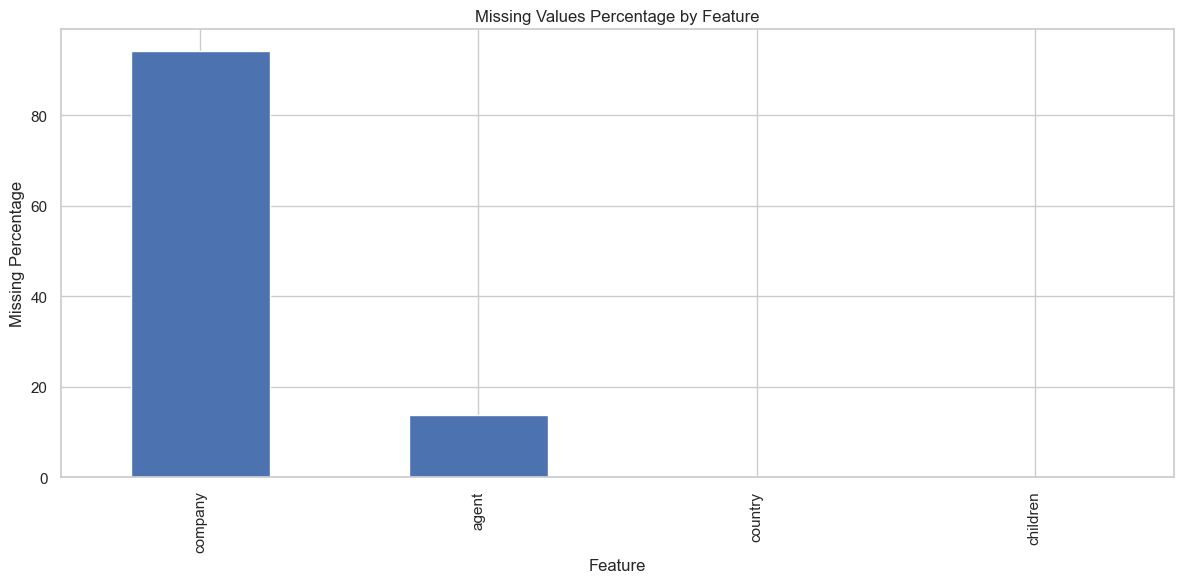

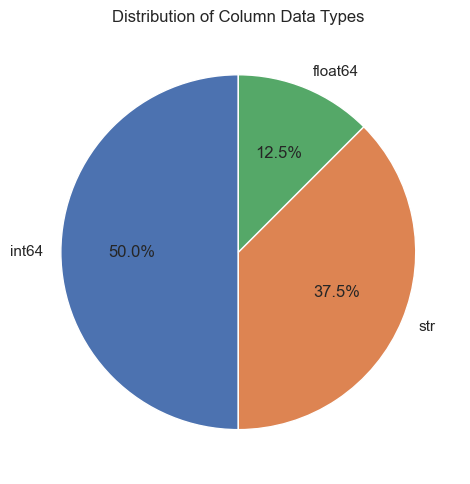

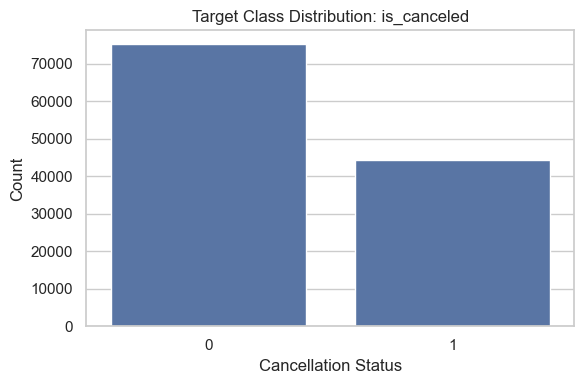

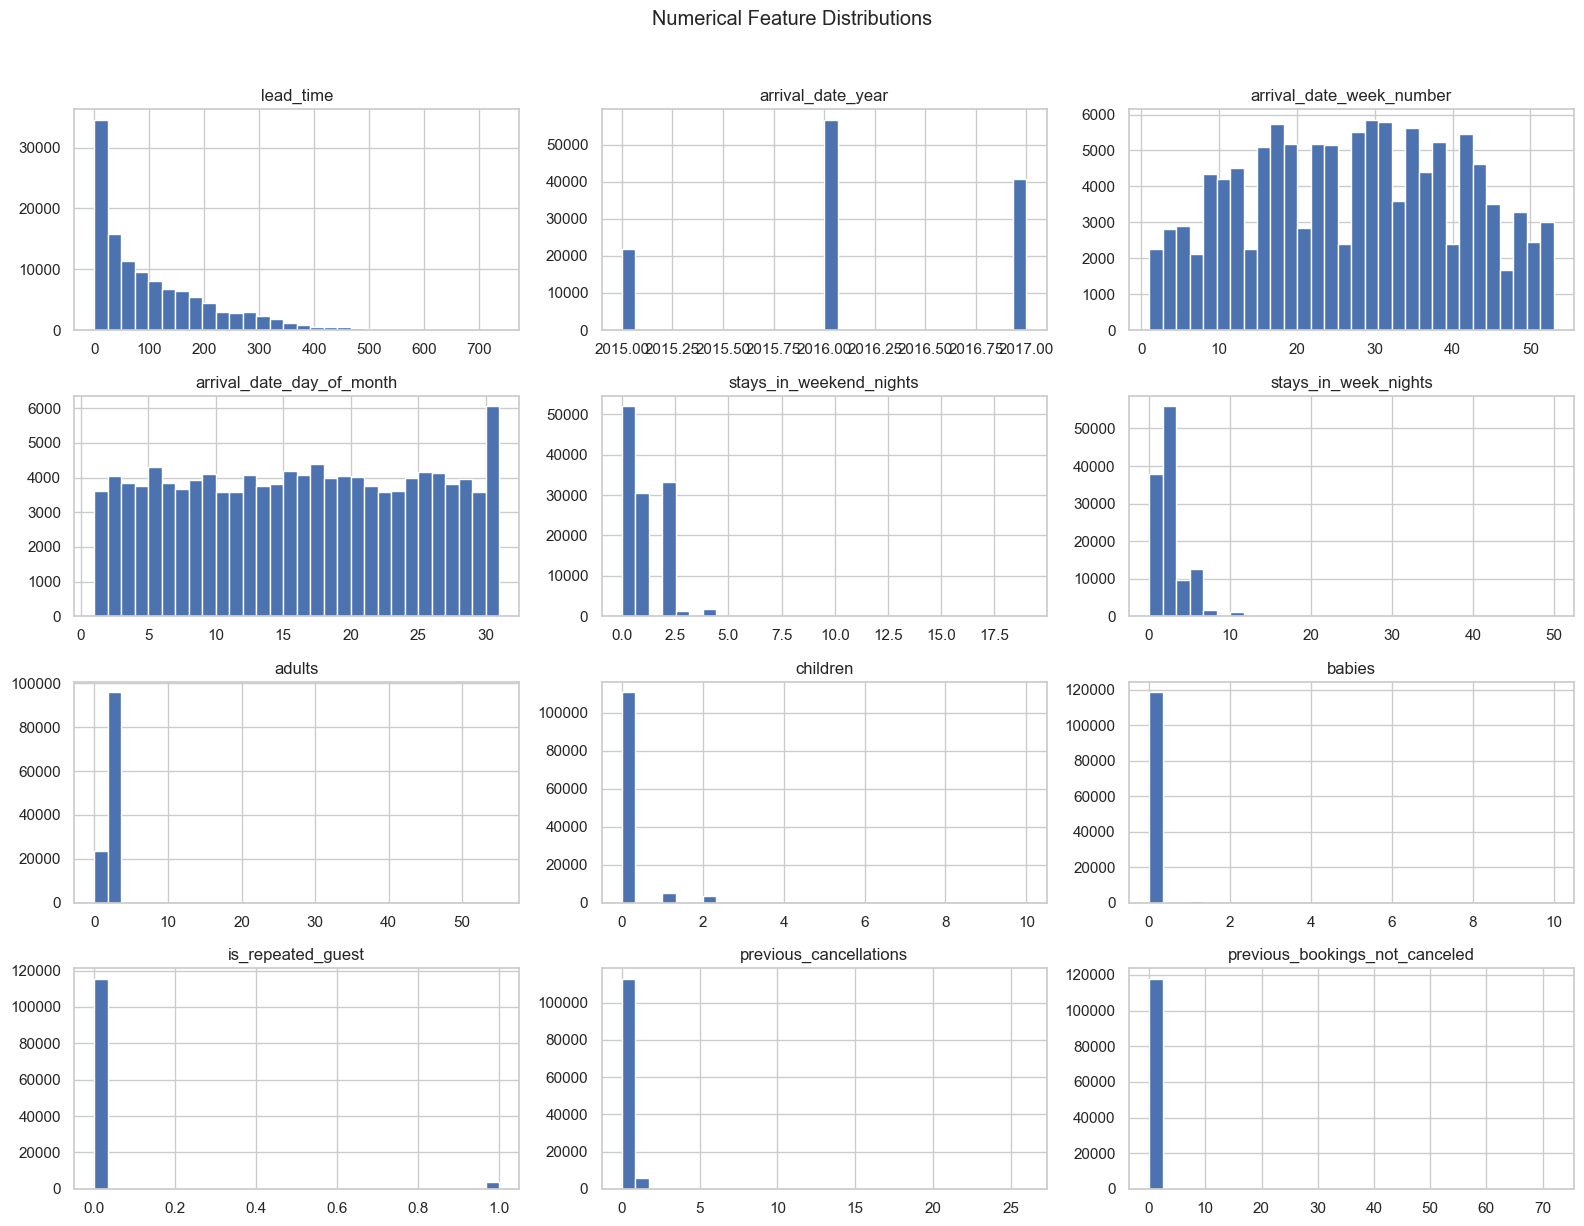

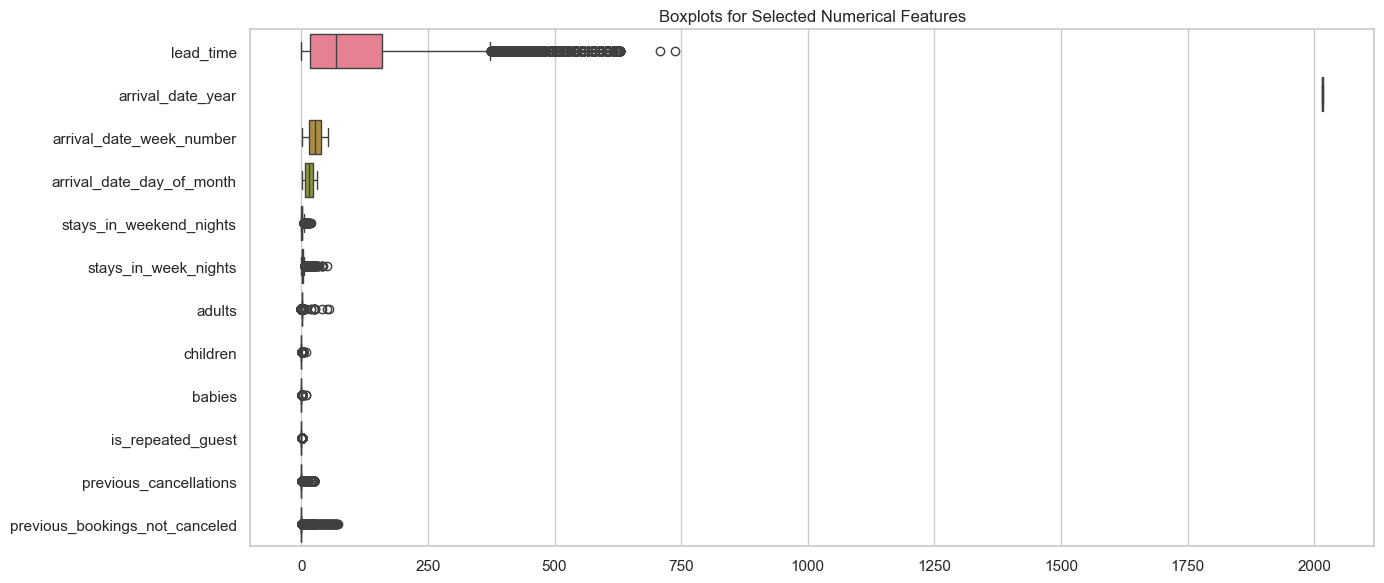

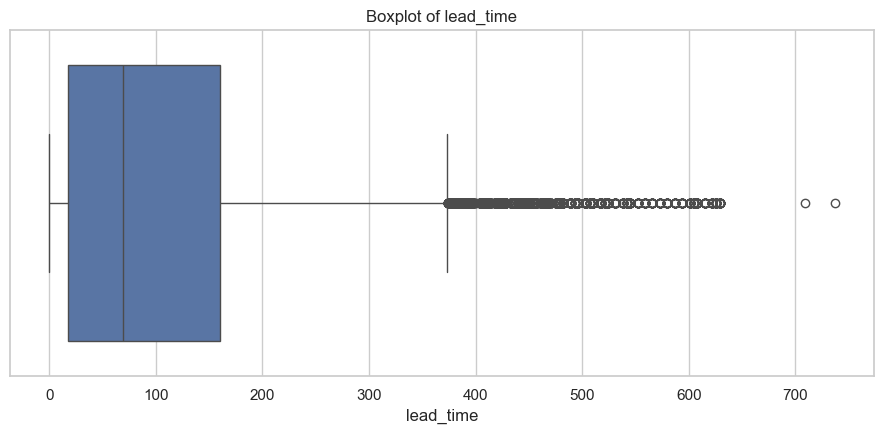

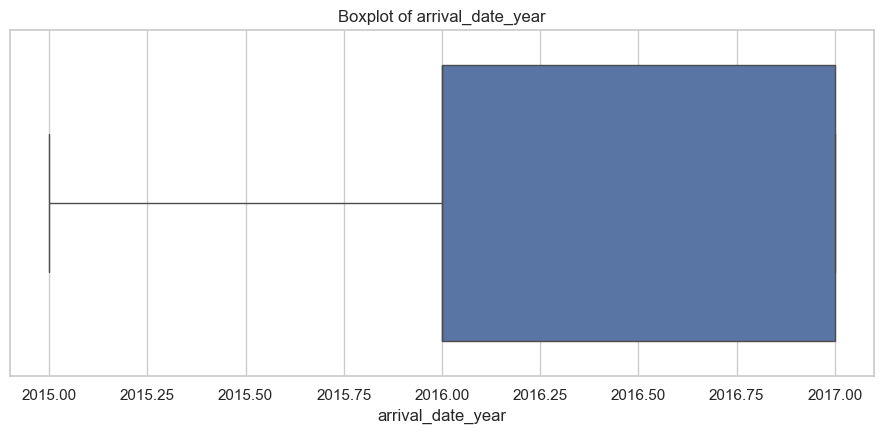

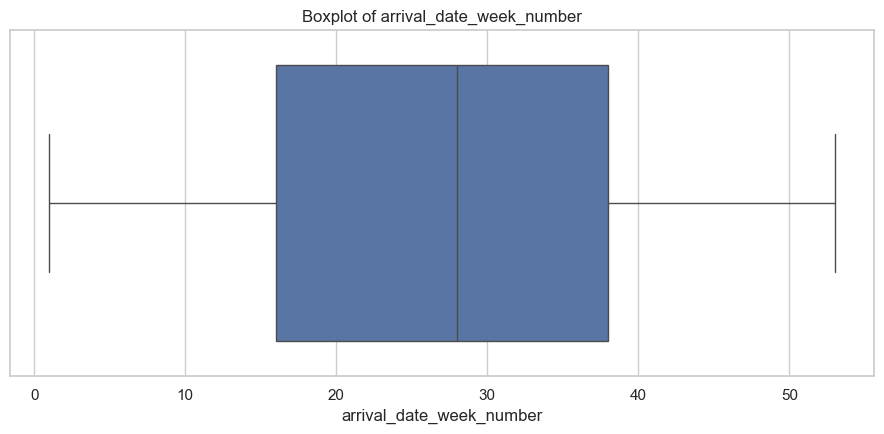

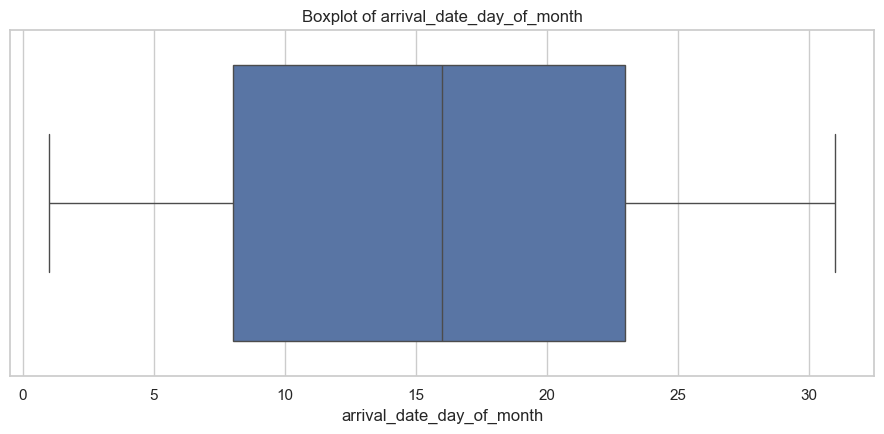

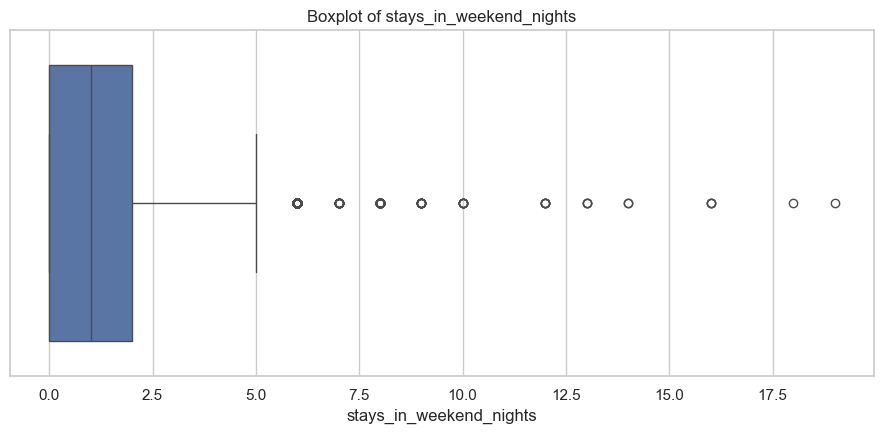

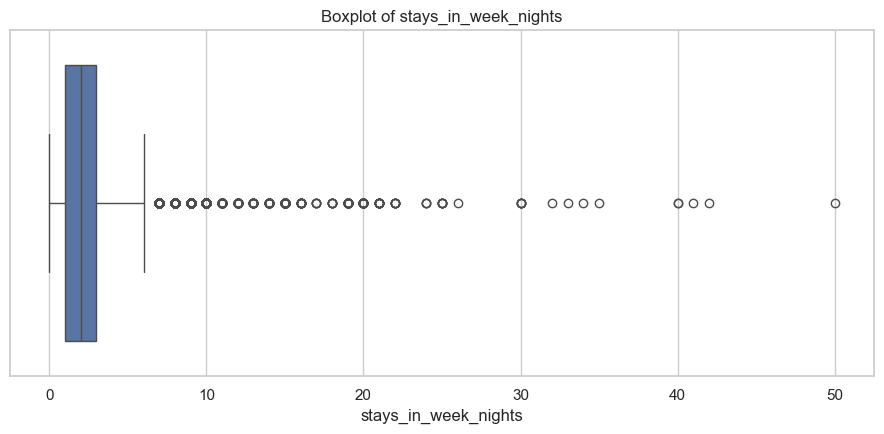

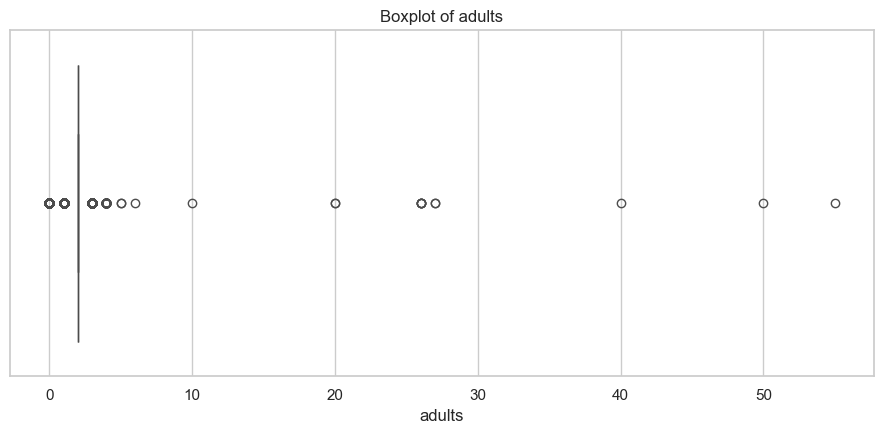

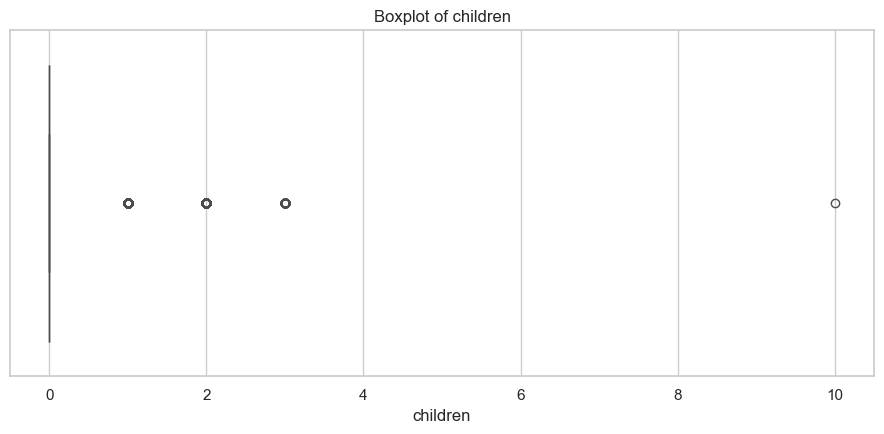

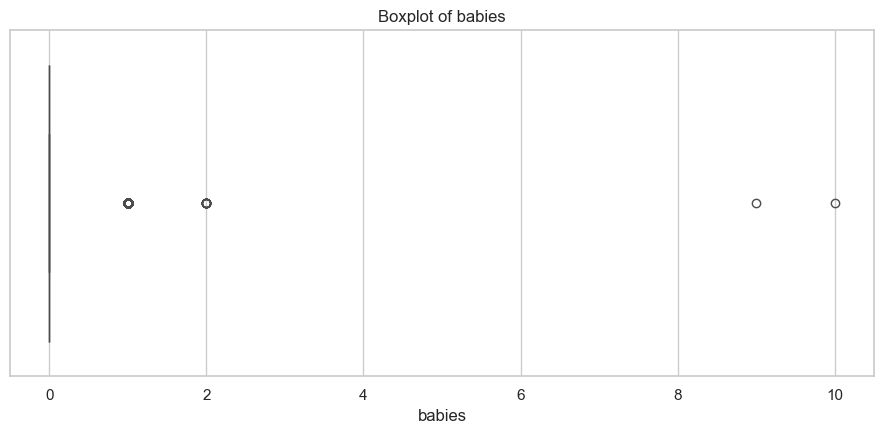

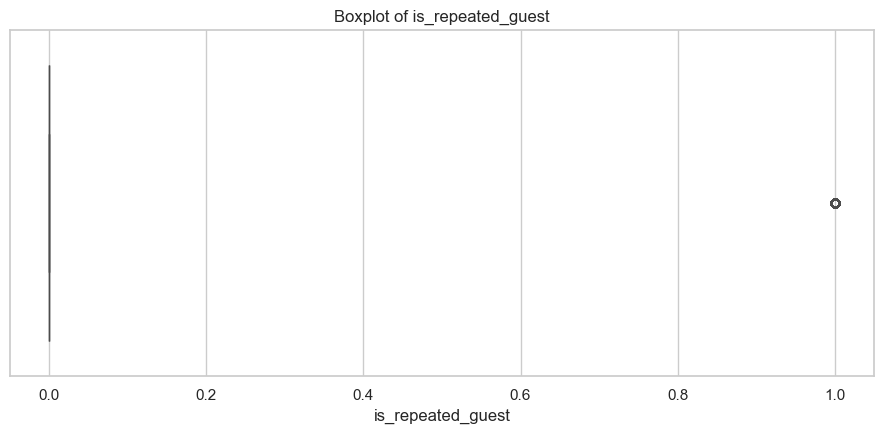

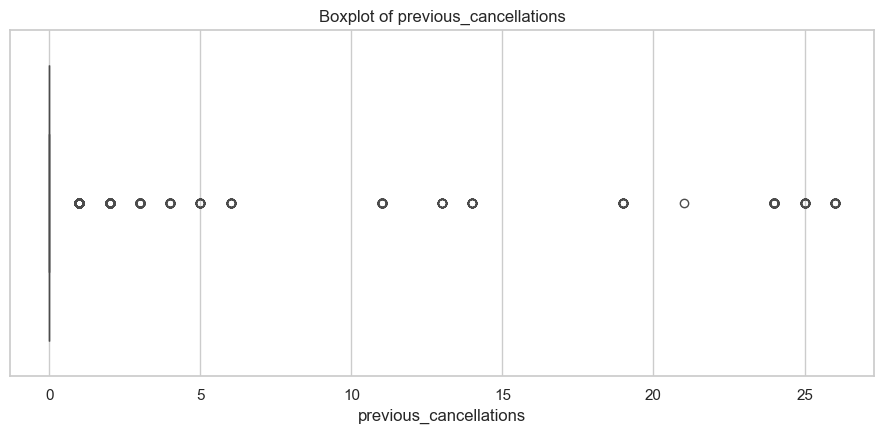

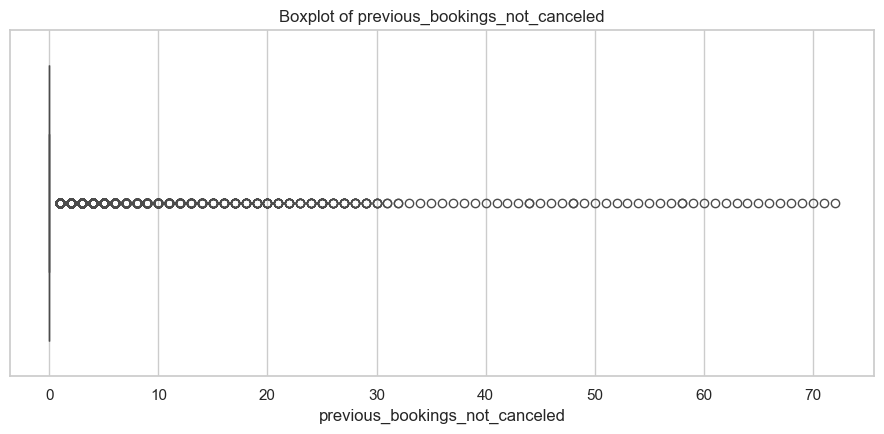

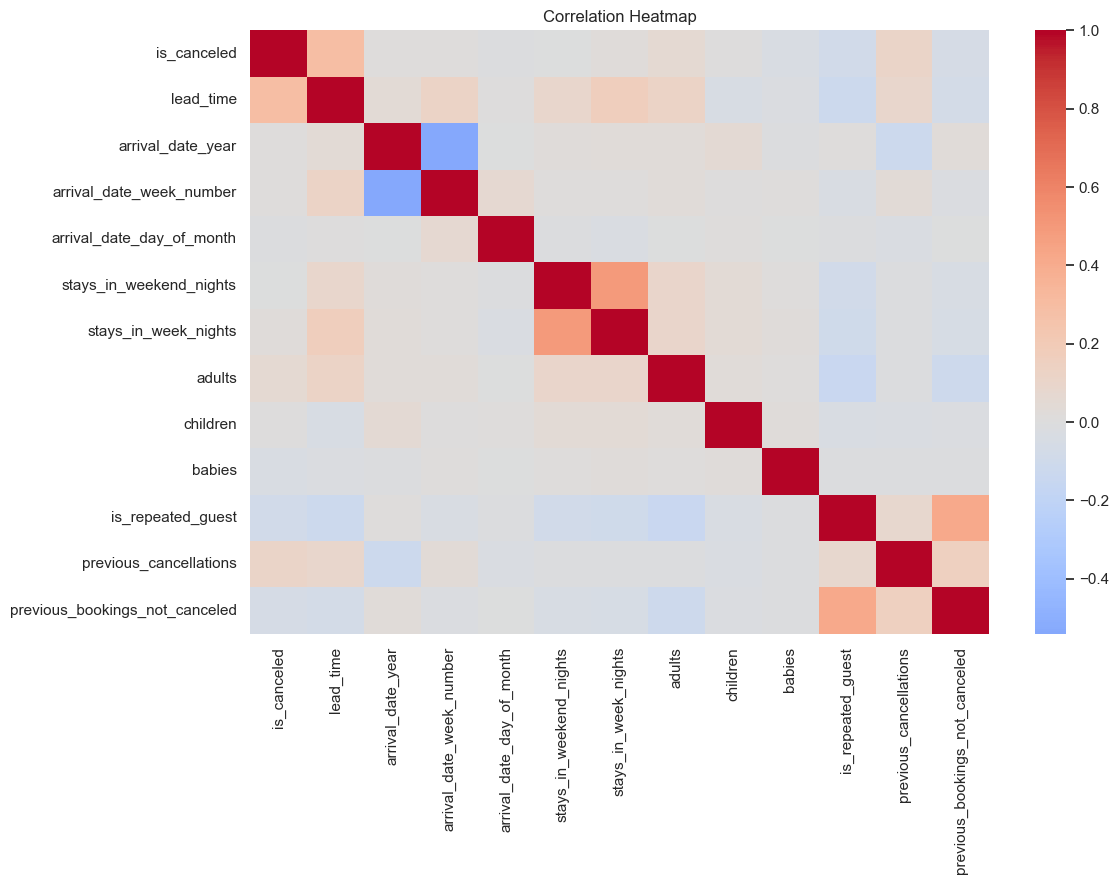

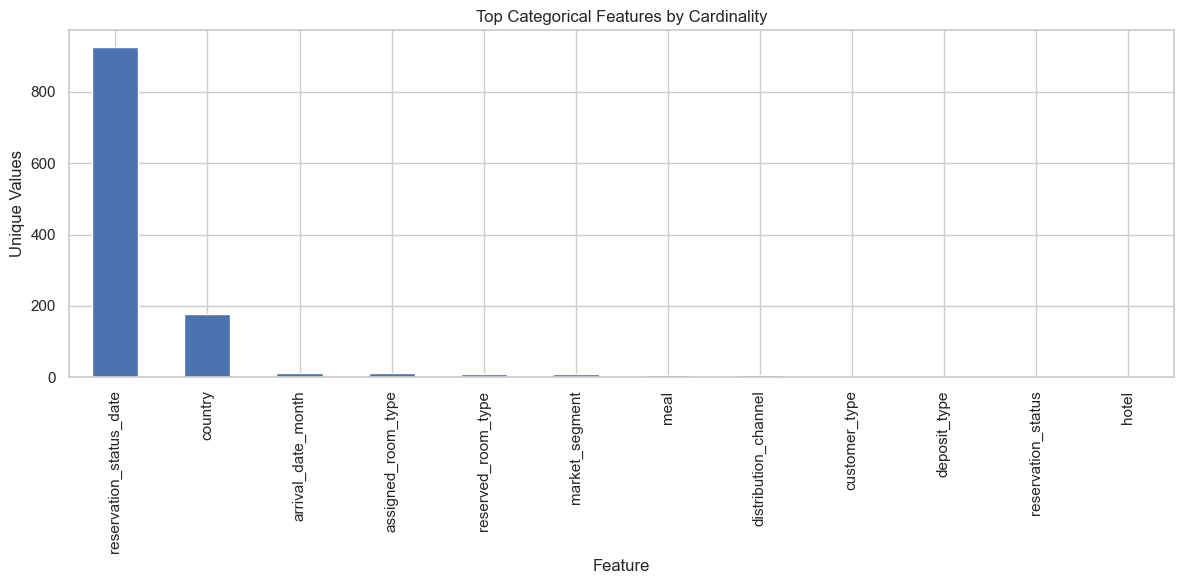

<Figure size 800x500 with 0 Axes>

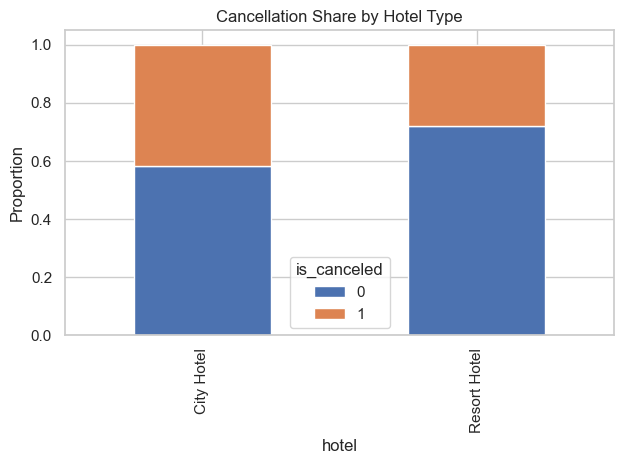

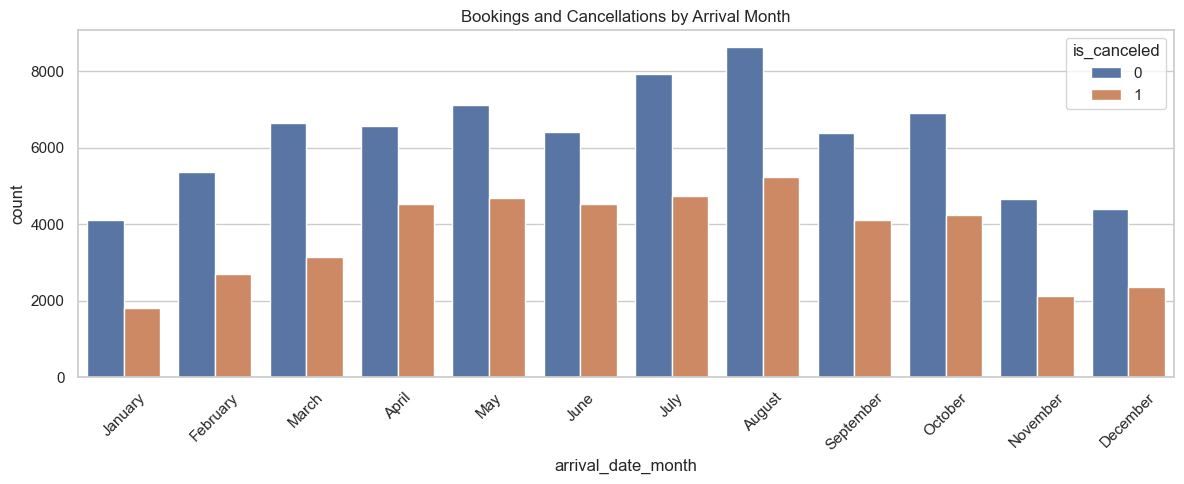

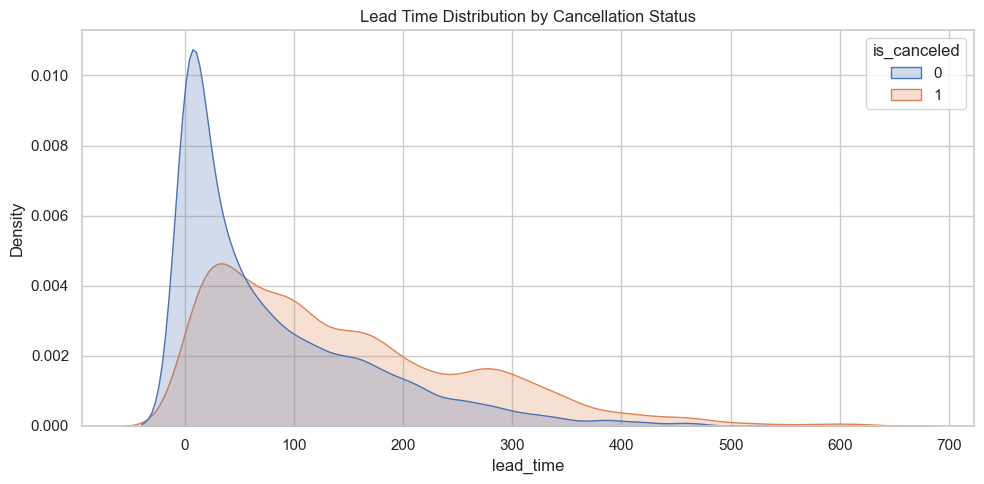

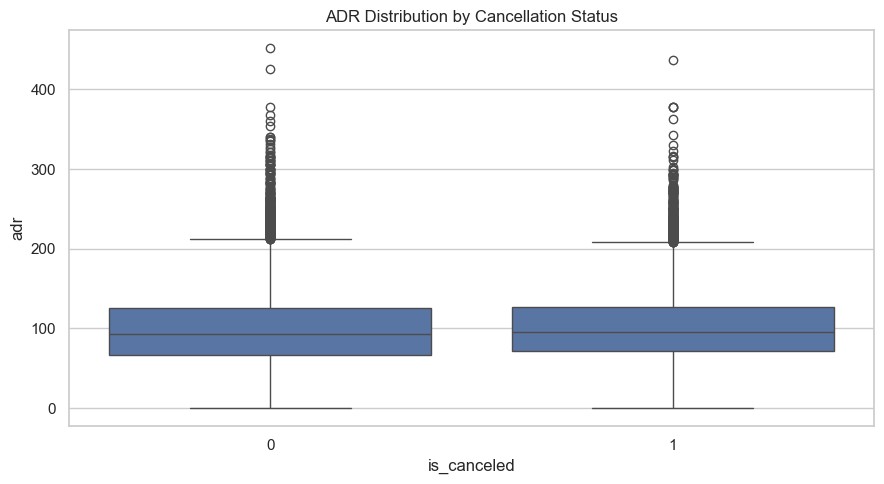

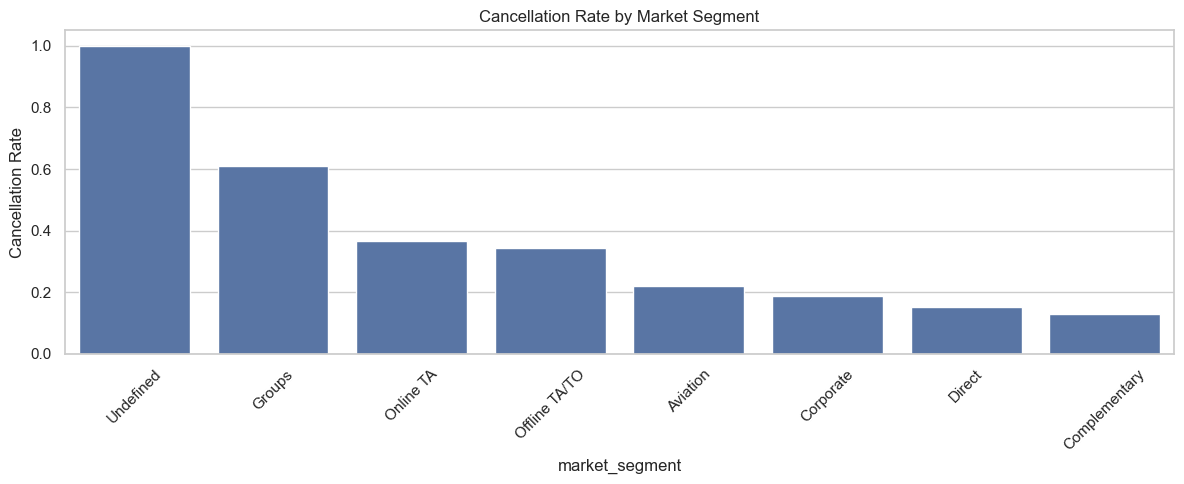

### Overview

,rows,columns,duplicate_rows,total_missing_cells,numeric_columns,categorical_columns,memory_usage_mb
0,119390,32,31994,129425,20,12,93.9


In [4]:
# ============================================================
# Cell 4: Save a dataset description bundle inside this model folder
# ============================================================
eda_bundle = create_dataset_description_bundle(
    df=df_raw,
    output_dir=OUTPUT_DIR,
    prefix="decision_tree_dataset",
    full=True,
)

display(Markdown("### Overview"))
display(pd.DataFrame([eda_bundle["overview"]]))

## 5. Data preprocessing and feature engineering

In [9]:
# ============================================================
# Cell 5: Apply domain-aware preprocessing before model pipelines
# ============================================================
df_model, preprocessing_notes = prepare_hotel_booking_dataframe(df_raw, target_col="is_canceled")

display(Markdown("### Preprocessing notes"))
preprocessing_notes_df = summarize_preprocessing_notes(preprocessing_notes)
display(preprocessing_notes_df)
preprocessing_notes_df.to_csv(OUTPUT_DIR / "preprocessing_summary_table.csv", index=False)

### Preprocessing notes

,item,value
0,initial_shape,"[119390, 32]"
1,duplicate_rows_removed,31994
2,dropped_columns,"[""reservation_status"", ""reservation_status_dat..."
3,engineered_features,"[""arrival_month_num"", ""arrival_season"", ""total..."
4,removed_rows,"{""zero_total_guests"": 166, ""negative_values_se..."
5,high_missing_columns,"{""company"": 93.98}"
6,leakage_columns_removed,"[""reservation_status"", ""reservation_status_date""]"
7,final_shape,"[87230, 37]"


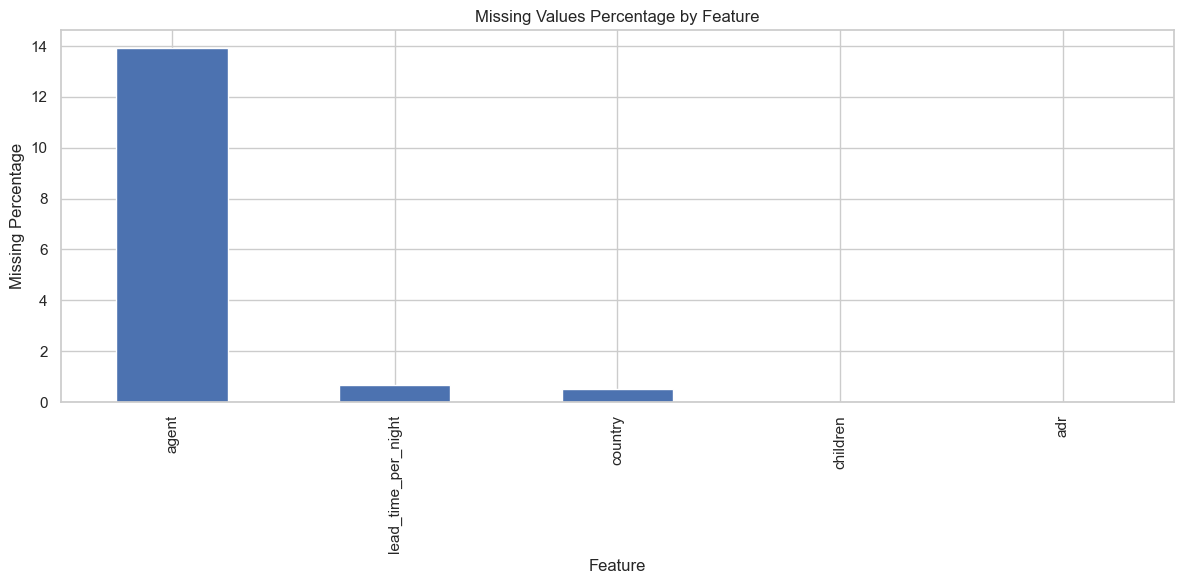

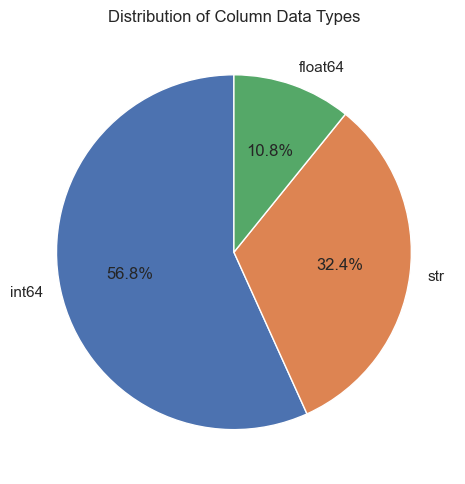

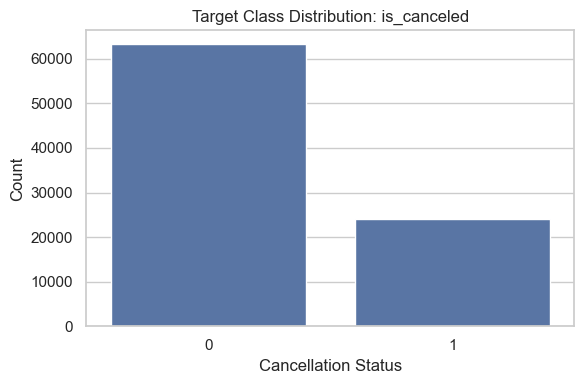

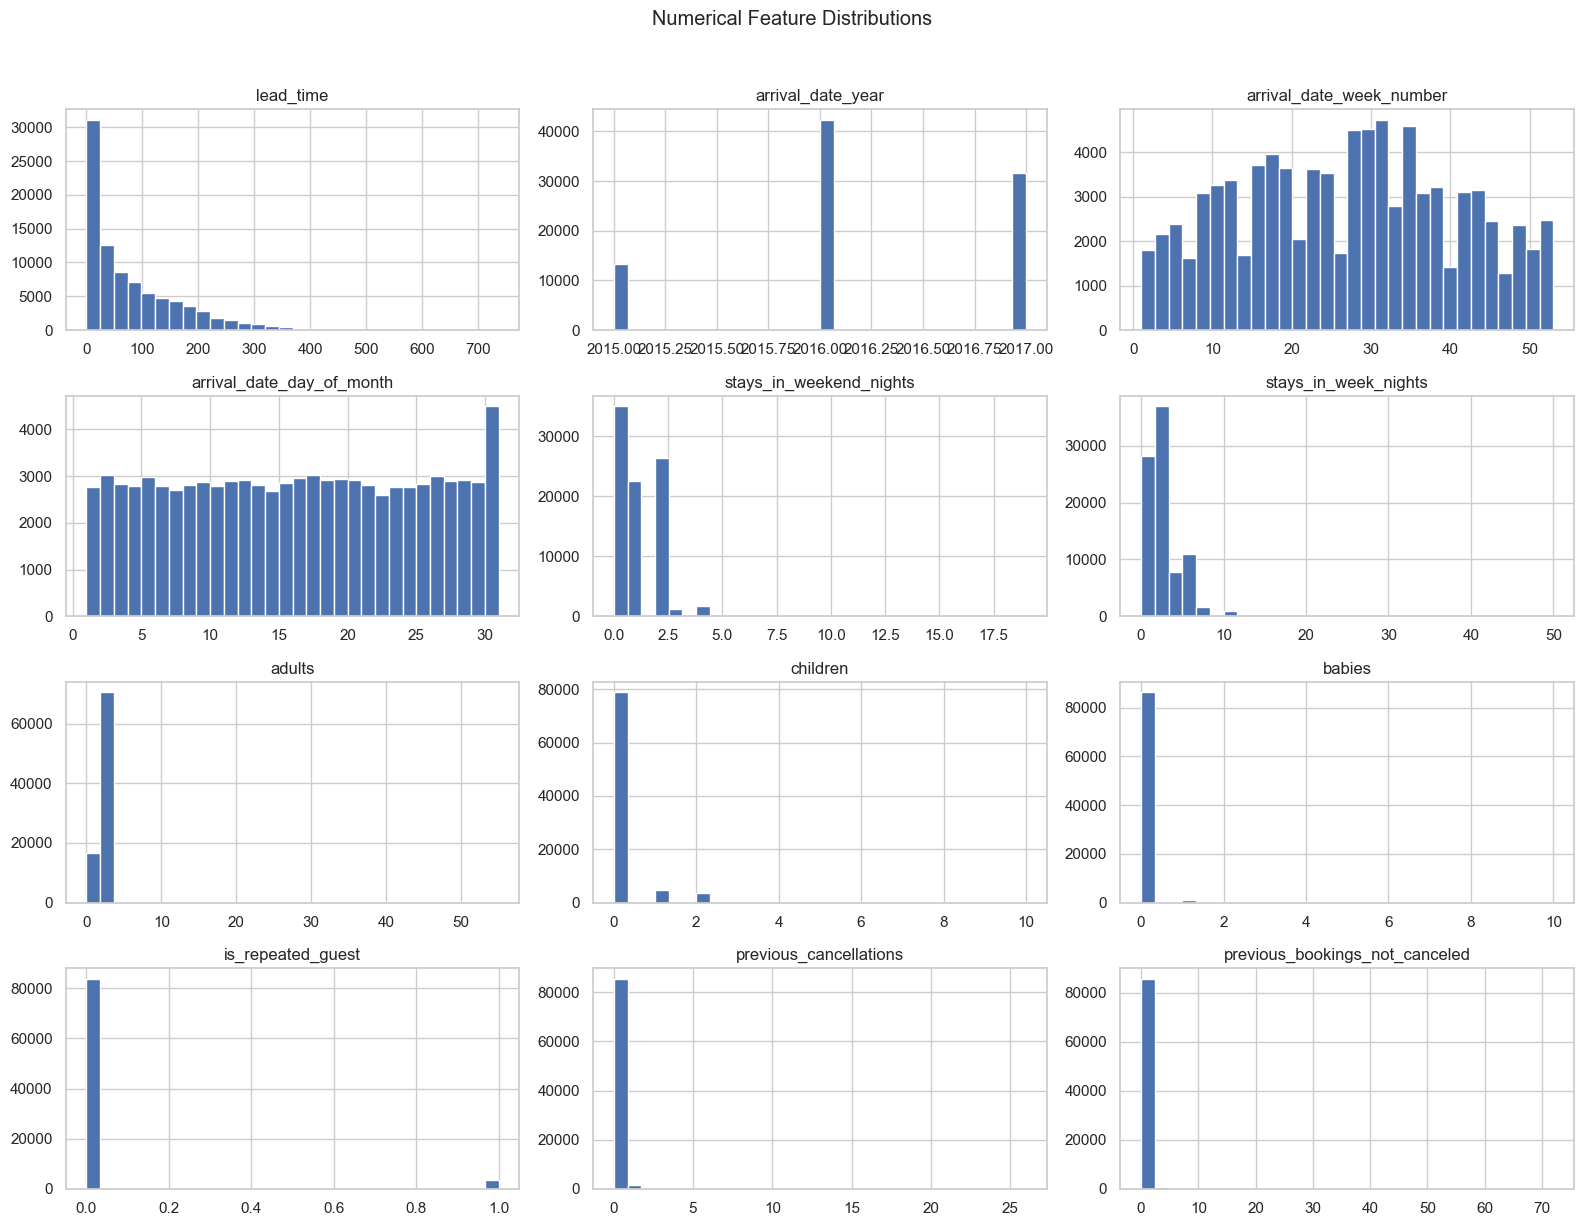

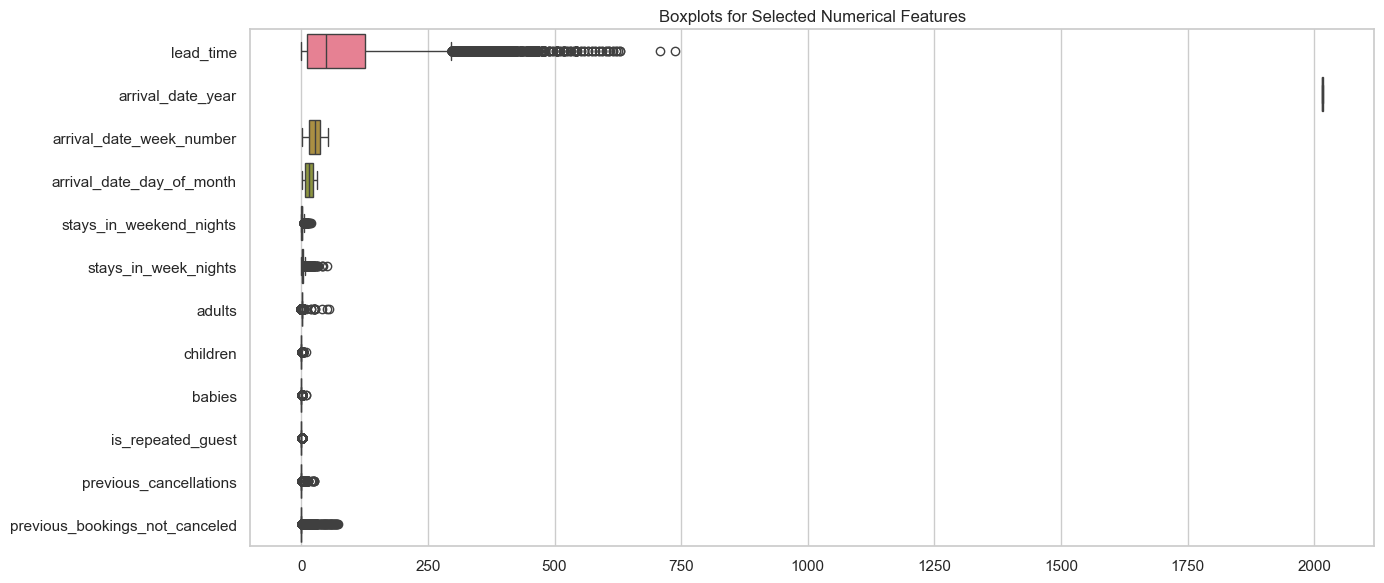

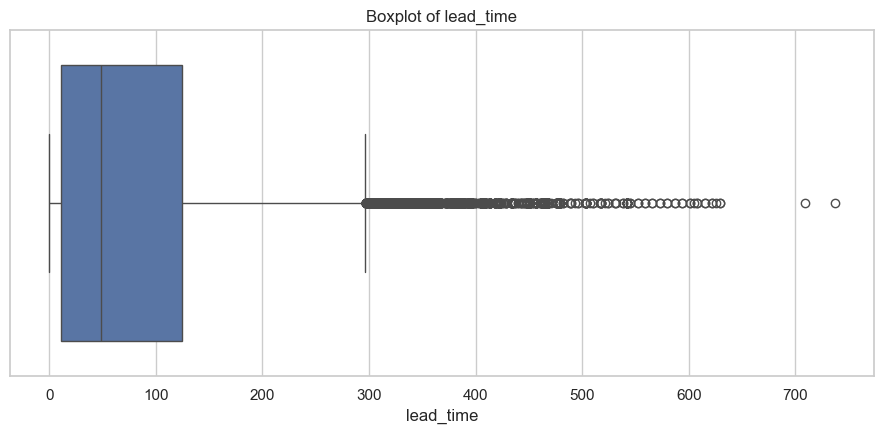

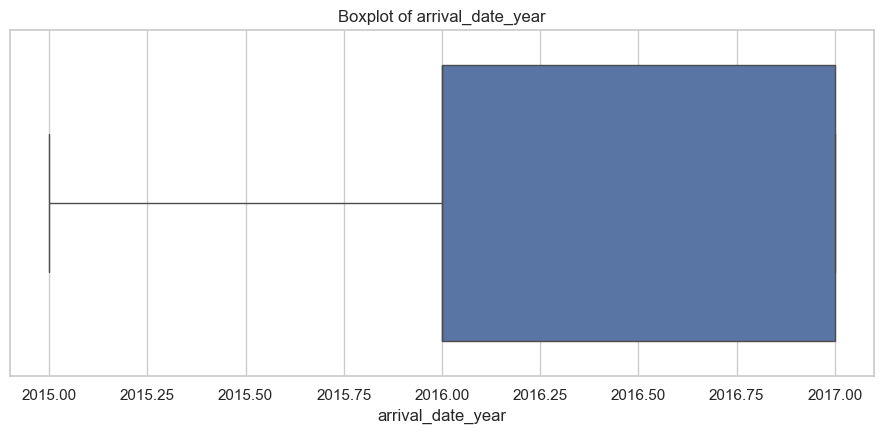

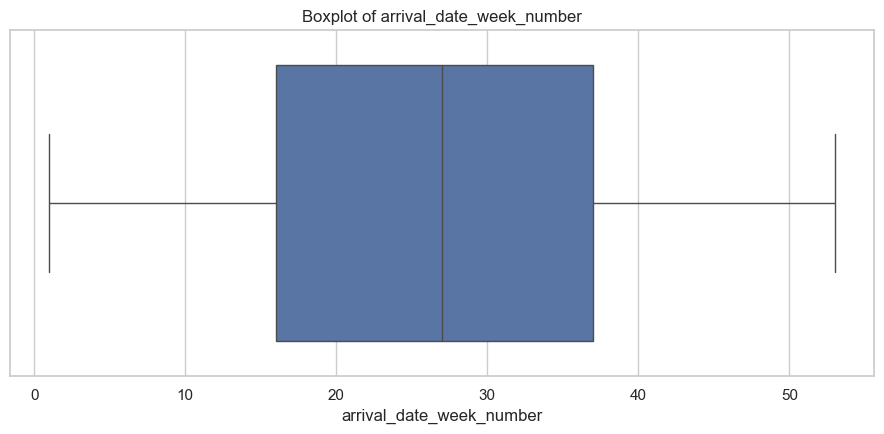

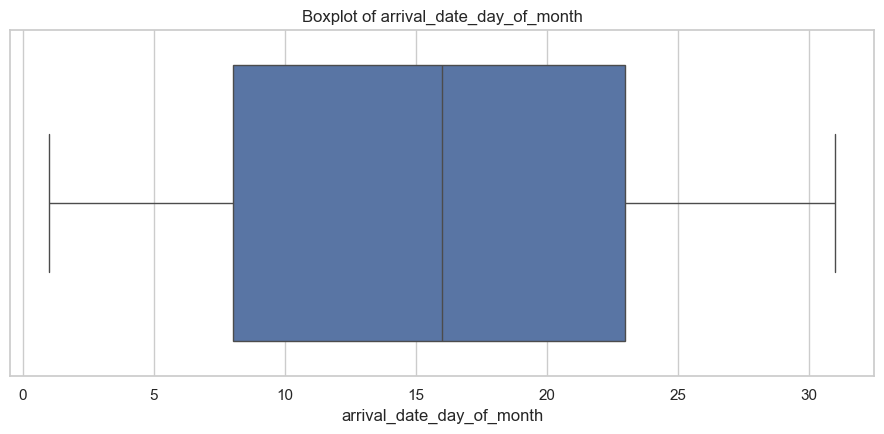

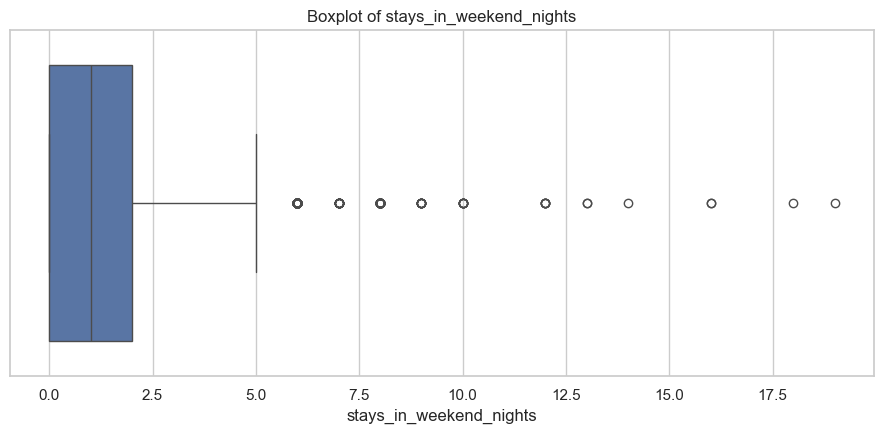

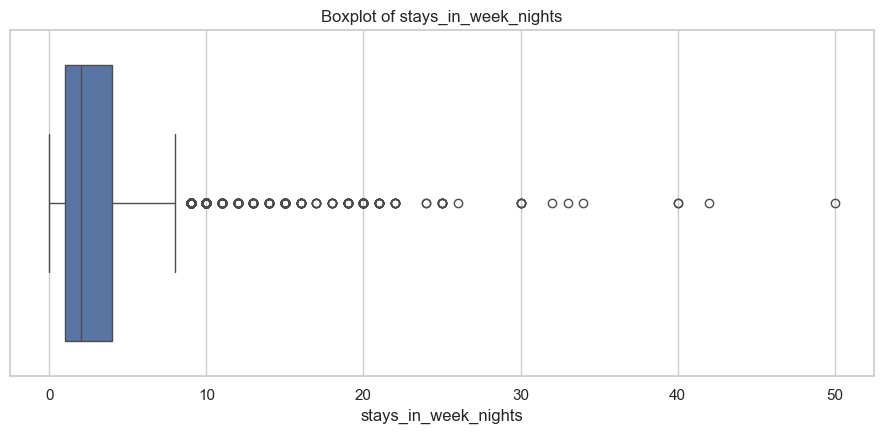

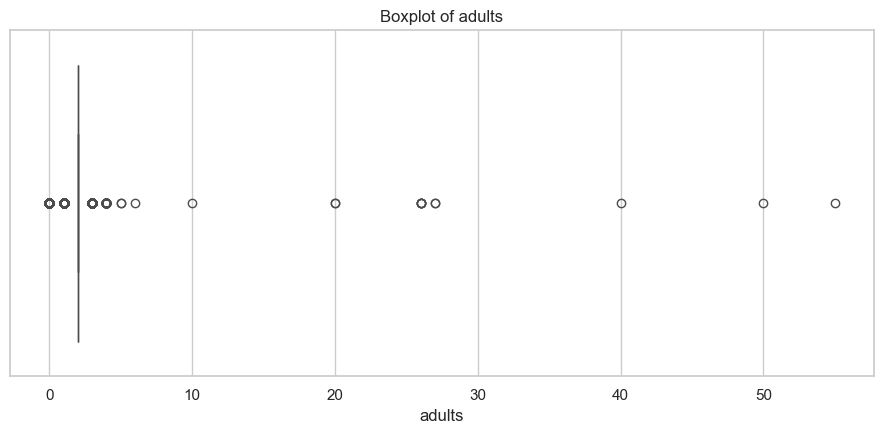

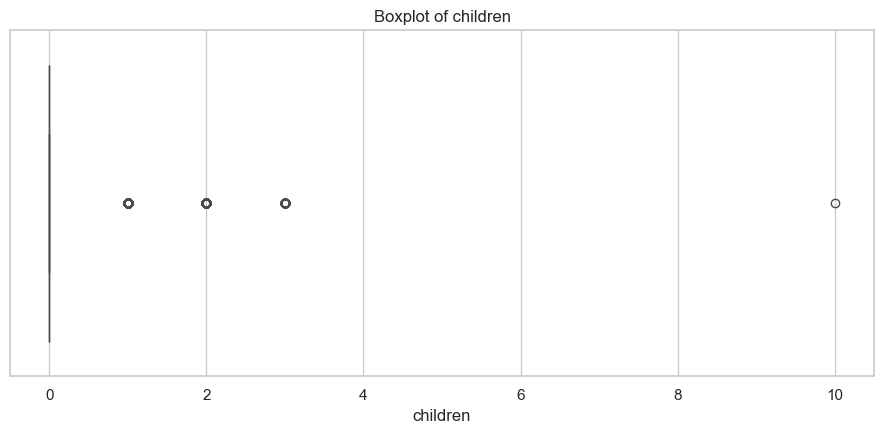

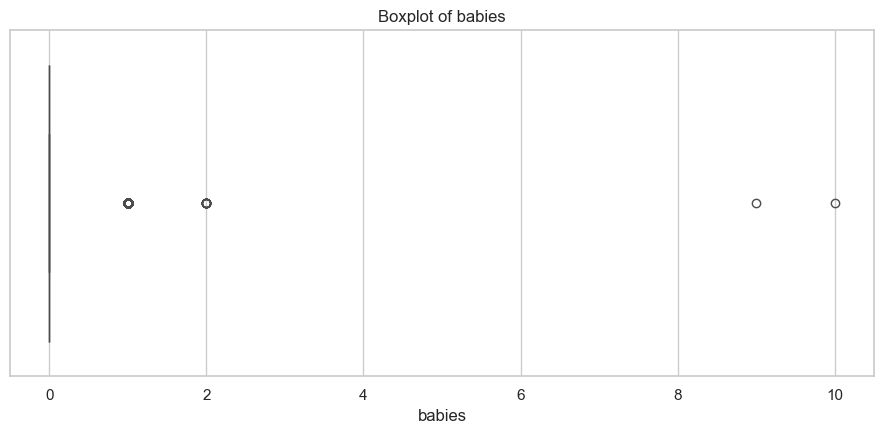

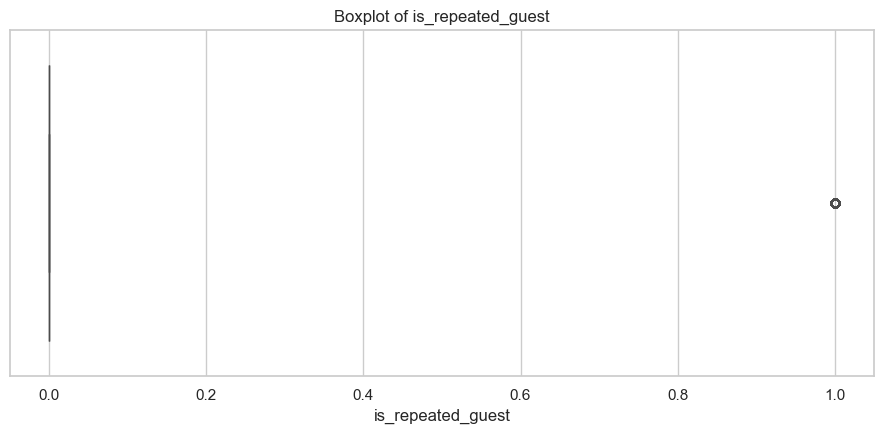

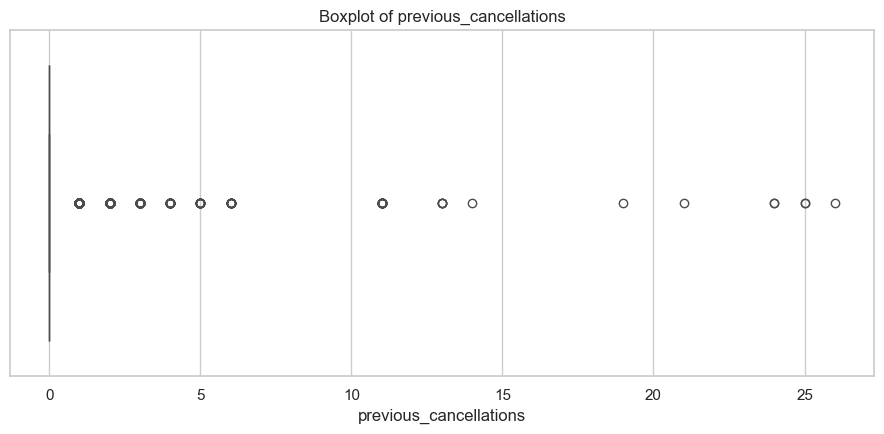

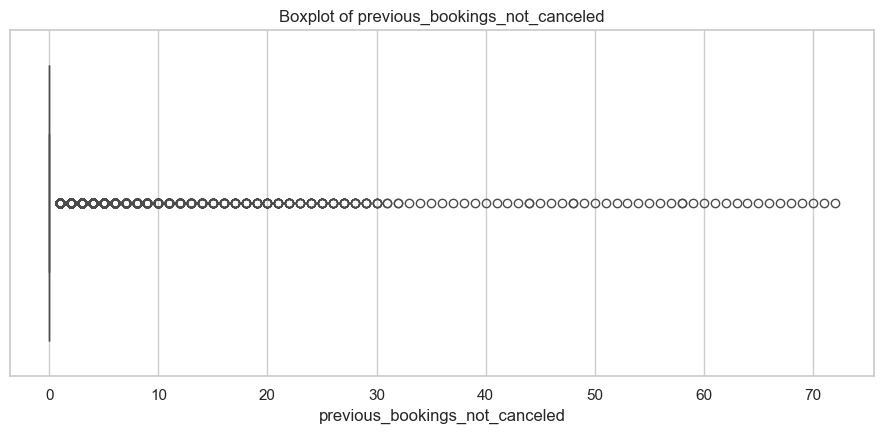

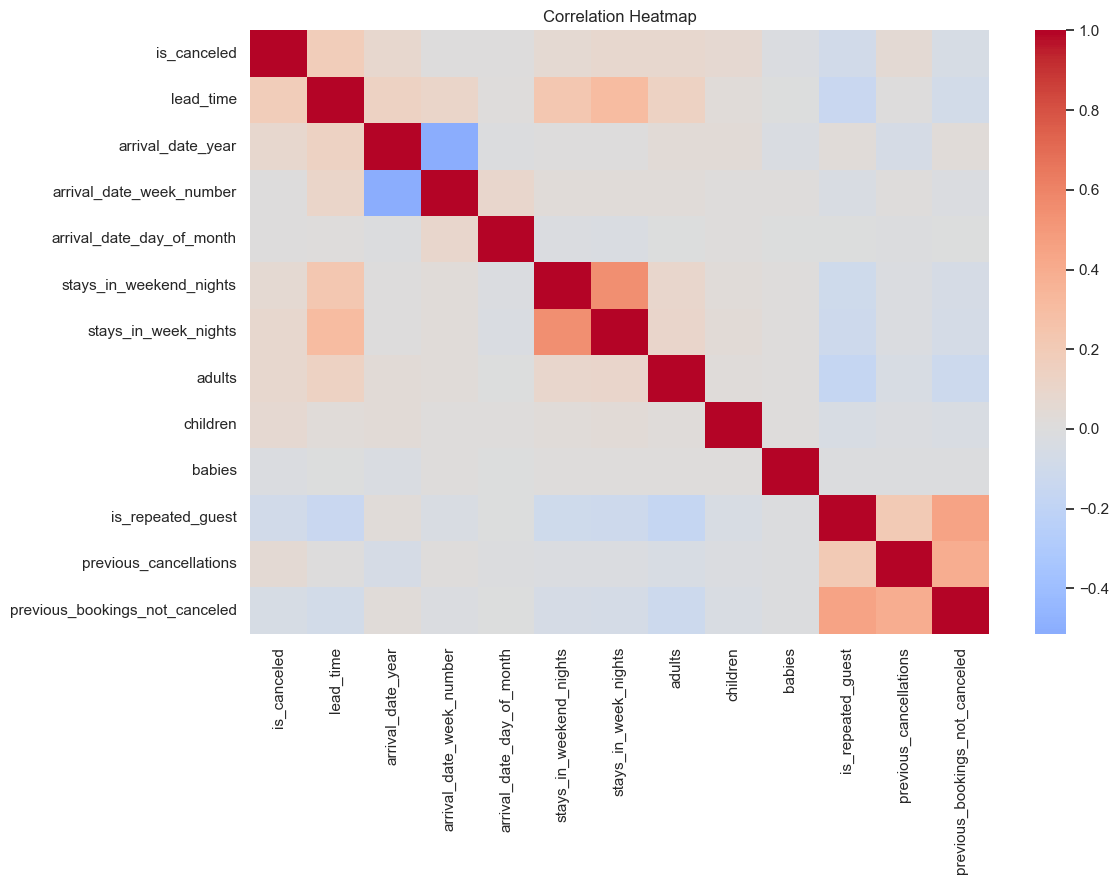

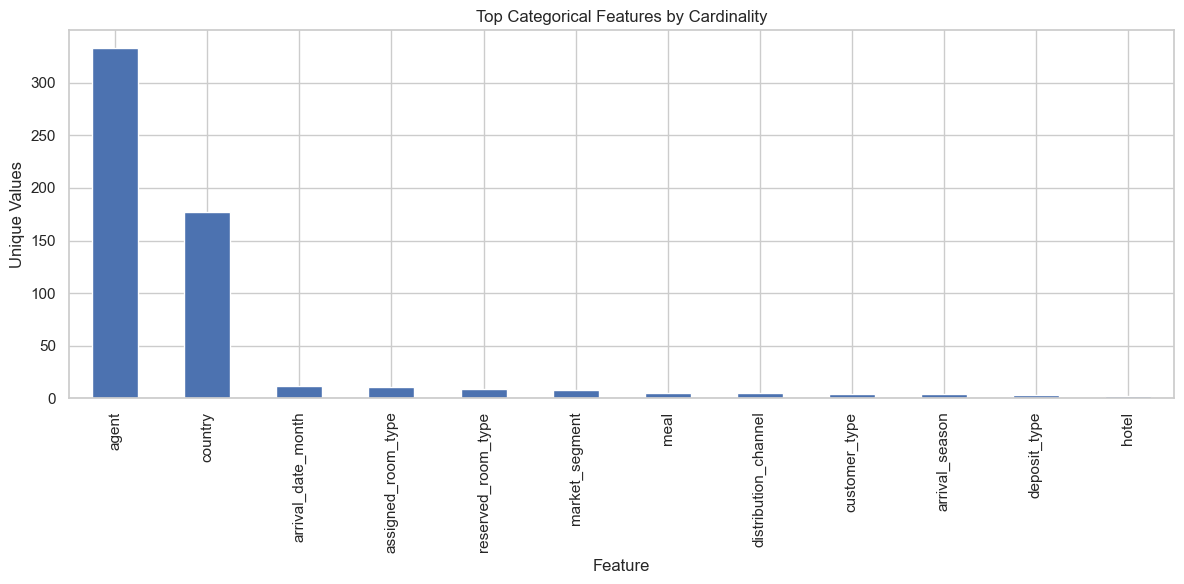

<Figure size 800x500 with 0 Axes>

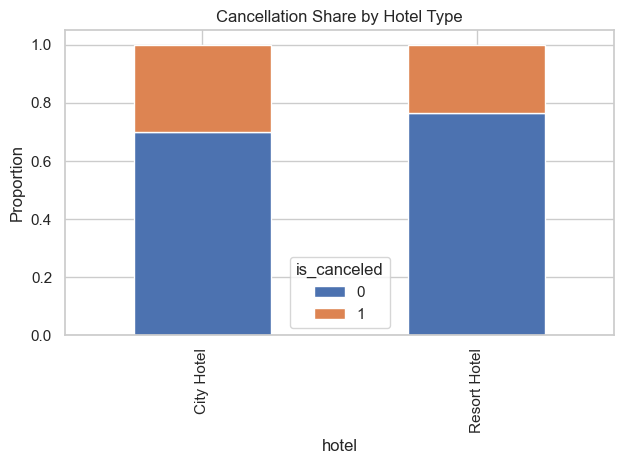

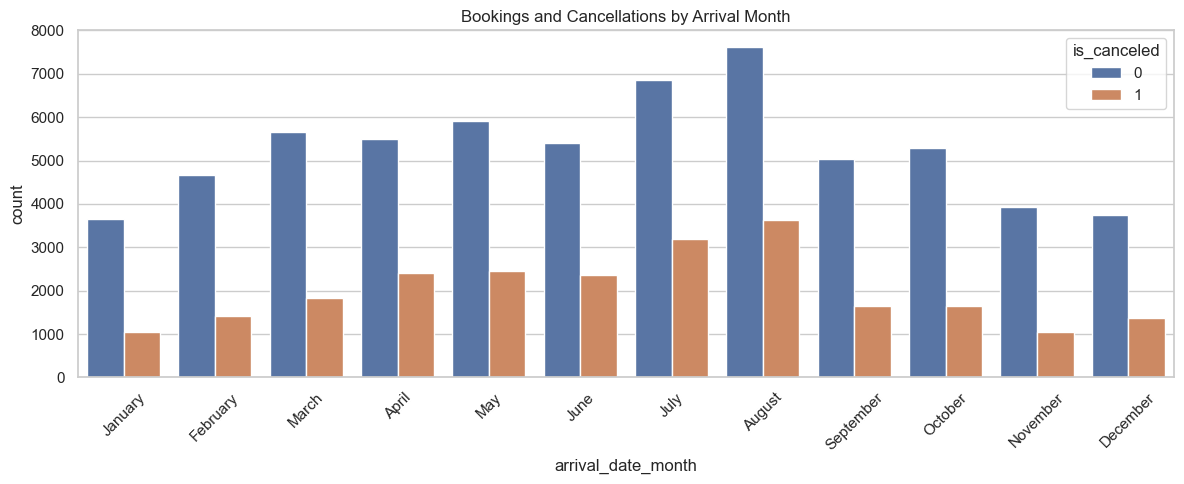

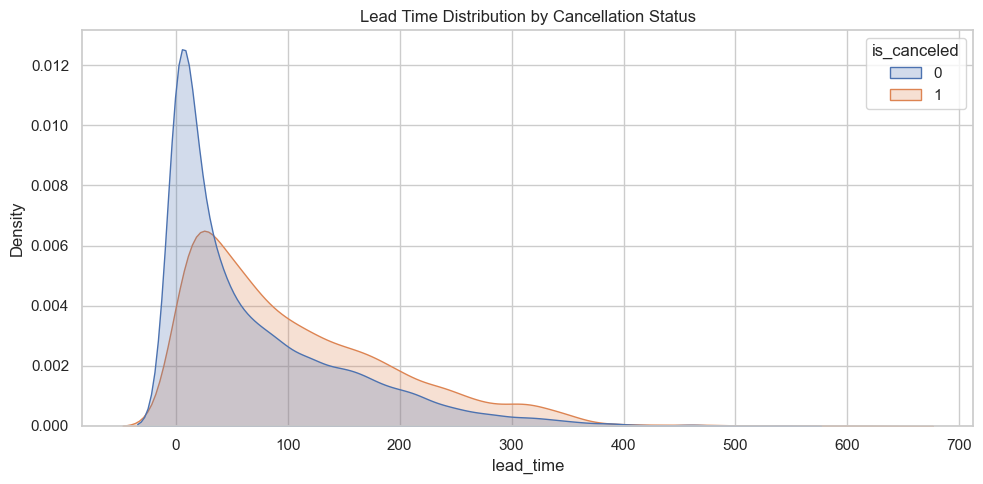

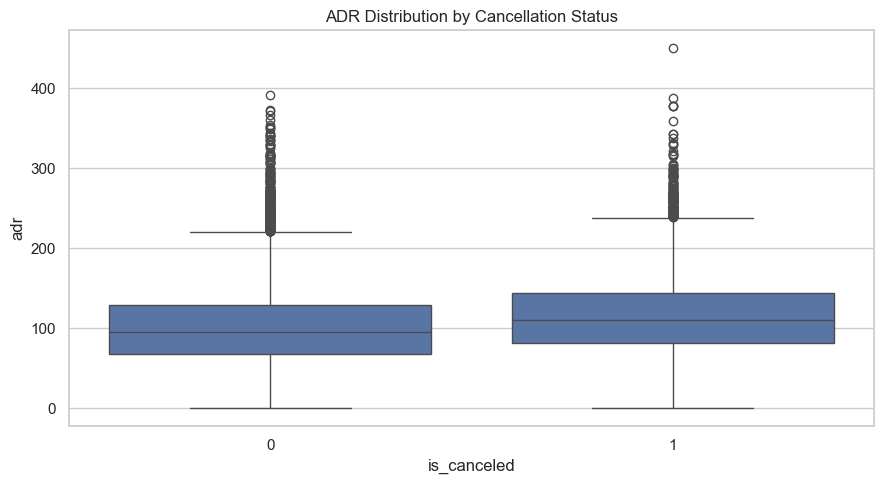

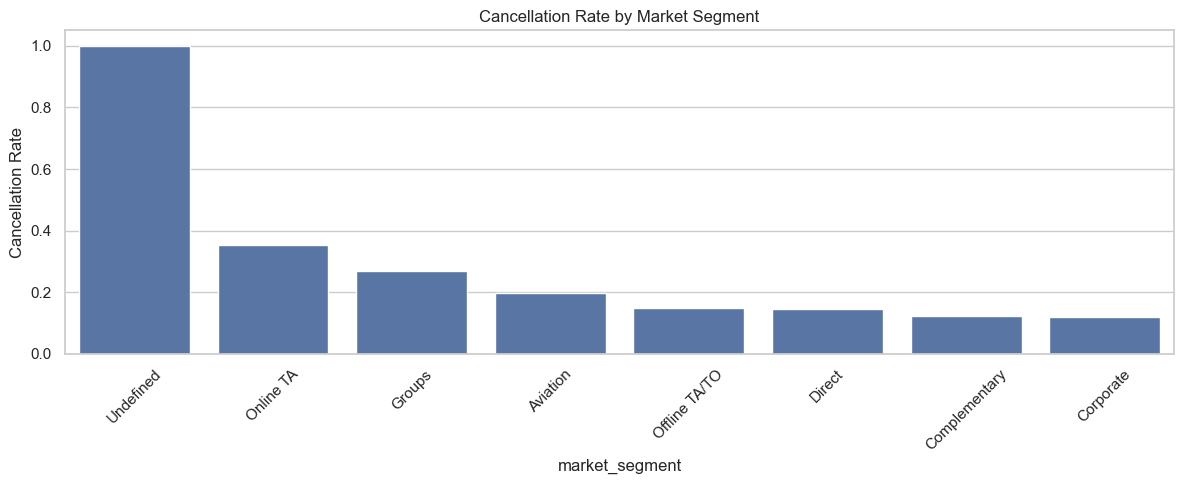

### Overview

,rows,columns,duplicate_rows,total_missing_cells,numeric_columns,categorical_columns,memory_usage_mb
0,87230,37,266,13184,25,12,70.8


In [10]:
# ============================================================
# Cell 4: Save a dataset description bundle inside this model folder
# ============================================================
eda_bundle = create_dataset_description_bundle(
    df=df_model,
    output_dir=OUTPUT_DIR,
    prefix="decision_tree_dataset_preprocessed",
    full=True,
)

display(Markdown("### Overview"))
display(pd.DataFrame([eda_bundle["overview"]]))

## 6. Train-test split and feature grouping

In [11]:
# ============================================================
# Cell 6: Create a reproducible split and identify feature groups
# ============================================================
X_train, X_test, y_train, y_test = build_train_test_split(
    df_model,
    target_col="is_canceled",
    test_size=0.20,
    random_state=RANDOM_STATE,
)

feature_cols, numeric_cols, categorical_cols = get_feature_groups(df_model, target_col="is_canceled")

print(f"Training rows: {X_train.shape[0]}")
print(f"Testing rows: {X_test.shape[0]}")
print(f"Numeric features: {len(numeric_cols)}")
print(f"Categorical features: {len(categorical_cols)}")

Training rows: 69784
Testing rows: 17446
Numeric features: 24
Categorical features: 12


## 7. Build model pipeline

In [13]:
# ============================================================
    # Cell 7: Build the preprocessing pipeline and model object
    # ============================================================
preprocessor = build_preprocessor("decision_tree", numeric_cols, categorical_cols)


classifier = DecisionTreeClassifier(
    random_state=RANDOM_STATE,
)


pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", classifier),
])

display(pipeline)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

## 8. Hyperparameter tuning setup

In [14]:
# ============================================================
    # Cell 8: Configure cross-validation and hyperparameter search
    # ============================================================
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


param_distributions = {
    "classifier__criterion": ["gini", "entropy", "log_loss"],
    "classifier__max_depth": [4, 6, 8, 12, 16, 24, None],
    "classifier__min_samples_split": [2, 5, 10, 20, 40],
    "classifier__min_samples_leaf": [1, 2, 5, 10, 20],
    "classifier__class_weight": [None, "balanced"],
    "classifier__ccp_alpha": [0.0, 0.0001, 0.001, 0.01],
}

search_object = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=30,
    scoring="roc_auc",
    cv=cv_strategy,
    n_jobs=-1,
    verbose=1,
    random_state=RANDOM_STATE,
    refit=True,
)


print(search_object)

RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('clipper',
                                                                                                IQRClipper())]),
                                                                               ['lead_time',
                                                                                'arrival_date_year',
                                                                                'arrival_date_week_number',
          

## 9. Train the model

In [15]:
# ============================================================
# Cell 9: Fit the hyperparameter search on the training data
# ============================================================
search_object.fit(X_train, y_train)

print("Best CV score:", search_object.best_score_)
print("Best parameters:", search_object.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


KeyboardInterrupt: 

## 10. Save cross-validation results

In [ ]:
# ============================================================
# Cell 10: Save hyperparameter tuning results and best parameters
# ============================================================
cv_results_df = save_cv_results(search_object, OUTPUT_DIR)
display(cv_results_df.head(10))
save_json(search_object.best_params_, OUTPUT_DIR / "best_params_pretty.json")

## 11. Evaluate on the hold-out test set

In [ ]:
# ============================================================
# Cell 11: Evaluate the best model and save all test metrics
# ============================================================
best_model = search_object.best_estimator_
metrics = evaluate_classifier(
    model=best_model,
    X_test=X_test,
    y_test=y_test,
    output_dir=OUTPUT_DIR,
    model_name="Decision Tree",
    threshold=0.50,
)

display(pd.DataFrame([metrics]))

## 12. Model interpretation

In [ ]:
# ============================================================
# Cell 12: Save coefficients or feature importances for interpretation
# ============================================================
feature_insights_df = save_feature_insights(
    model=best_model,
    output_dir=OUTPUT_DIR,
    model_name="Decision Tree",
    top_n=20,
)

if not feature_insights_df.empty:
    display(feature_insights_df.head(20))
else:
    print("No feature importance or coefficient table is available for this model.")

## 13. Save the trained model

In [ ]:
# ============================================================
# Cell 13: Save the best trained pipeline and metadata for reuse
# ============================================================
save_model_bundle(
    model=best_model,
    output_dir=OUTPUT_DIR,
    model_filename="best_model.joblib",
    best_params=search_object.best_params_,
    preprocessing_notes=preprocessing_notes,
)

print(f"Saved model and metadata to: {OUTPUT_DIR}")

## 14. Save a short run report

In [ ]:
# ============================================================
# Cell 14: Write a short text report for quick review
# ============================================================
run_report_lines = [
    "# Decision Tree Run Report",
    "",
    f"- Dataset file: {dataset_path.name}",
    f"- Raw dataset shape: {df_raw.shape}",
    f"- Modeling dataset shape: {df_model.shape}",
    f"- Best CV score: {search_object.best_score_:.6f}",
    f"- Best parameters: {search_object.best_params_}",
    f"- Test accuracy: {metrics['accuracy']:.6f}",
    f"- Test precision: {metrics['precision']:.6f}",
    f"- Test recall: {metrics['recall']:.6f}",
    f"- Test F1 score: {metrics['f1']:.6f}",
    f"- Test ROC-AUC: {metrics['roc_auc']:.6f}",
    f"- Test MCC: {metrics['mcc']:.6f}",
    "",
    "## Critical analysis prompts",
    "- Review whether the model overfits by comparing CV performance with test performance.",
    "- Explain how the preprocessing steps influenced model behavior.",
    "- Discuss what future feature engineering or threshold tuning could improve recall or MCC."
]

run_report_path = OUTPUT_DIR / "run_report.md"
run_report_path.write_text("\n".join(run_report_lines), encoding="utf-8")
print(f"Saved run report to: {run_report_path}")